# III) Single material optimization


## 1) Geometry

First, we define the geometry, material distribution, and generate the mesh.

In [1]:
pole_pairs = 6
bundles_per_half_slot = 5

# Generate the corresponding mesh
from utils.geometry import machine_mesh
mesh = machine_mesh(p=pole_pairs, 
                    bundles_per_half_slot=bundles_per_half_slot, 
                    hBundle=0.25e-3
                    )

print(f"Generated mesh with {mesh.nv} nodes, {mesh.ne} elements")

Generated mesh with 15477 nodes, 30870 elements


________
## 2) Setup of the physical problem

See notebook [I_Reference_simulation](I_Reference_simulation.ipynb).

### 2.a) Material properties

In [2]:
mur_iron = 1000           # Relative magnetic permeability of iron core
sigma_copper = 5.8e7      # Copper conductivity (S/m)
Br = 1                    # Remanent flux density of magnets (T)


# Define space-varying material coefficients
from ngsolve import pi
mu0 = 4e-7 * pi
nu = mesh.MaterialCF({"core_stator" : 1 / (mu0 * mur_iron)}, default = 1/mu0)     # reluctivity
sigma = mesh.MaterialCF({"slot(.*)_bundle.*" : sigma_copper})                     # conductivity
from utils.physics import magnetization_halbach
Mcplx = mesh.MaterialCF({"rotor" : magnetization_halbach(br = Br, p=pole_pairs)}) # magnetization

### 2.b) Current supply

In [3]:
freq = 1000 # Electrical frequency (Hz)
Jrms = 10e6 # Current density (A/m²)
phi = 150   # load angle (°), chosen to maximize average torque
winding_type = "distributed" # "distributed" or "concentrated"

from ngsolve import Integrate
from utils.supply import phase_current, winding_arrangement, bundle_arrangement

S_bundle = Integrate(1, mesh.Materials("slot11_bundle0"))
Irms = Jrms * S_bundle
phase = phase_current(I_rms=Irms,  load_angle=phi*pi/180)
winding = winding_arrangement(phase, type = winding_type)
bundles = bundle_arrangement(winding, bundles_per_half_slot=bundles_per_half_slot)

### 2.c) Finite element space

In [4]:
curve_order = 2
fem_order = curve_order

from ngsolve import H1, Periodic
fes = Periodic( H1(mesh.Curve(curve_order), 
                   order = fem_order, 
                   dirichlet =  "shaft|out", 
                   complex = True),  [-1]*7 )
print(f"Number of degrees of freedom of the FE space: {fes.ndof}")

Number of degrees of freedom of the FE space: 61823


_________
## 3) Optimization of each bundle material

Too high conductivity leads to high AC losses, while too low conductivity leads to high DC losses. There is an optimum point that can be found. An optimization of the whole conductivity of a single material coil was conducted in [III_single_material_optimization](III_single_material_optimization.ipynb).
However, hairpin winding may enable a different conductivity per bundle.
The dimension of the optimization problem is now too big to apply an exhaustive search!

### 3.a) Setup of the optimization problem

The keypoint is the definition of the "gradient" that also defines the admissible variations of $\sigma$. In the present case the conductivity can vary independantly in each bundle.

In [5]:
# Problem parameters
sigma0 = sigma_copper         # initial conductivity
sigma_min = sigma_copper/10   # minimum admissible conductivity
sigma_max = sigma_copper      # maximum admissible conductivity

# Conductivity space
from ngsolve import L2, GridFunction
fes_sigma = L2(mesh, definedon = "slot(.*)_bundle.*")
x0 = GridFunction(fes_sigma)
x0.Set(sigma0)

In [6]:
# Definition of the functions of interest

from utils.physics import solve_magnetoharmonic, joule_losses
def state_function(conductivity):
    """ Returns the solution of the magnetoharmonic problem for a given conductivity value """
    result = solve_magnetoharmonic(fes=fes,
                                   reluctivity=nu,
                                   conductivity=conductivity,
                                   magnetization=Mcplx,
                                   frequency=freq,
                                   supply=bundles
                                   )
    return result

def objective_function(result):
    """ Total Joule losses to minimize """
    return joule_losses(result)

In [ ]:
# Algorithm parameters

from copy import copy
from numpy import sign

def descent(grad):
    """ Extract descent direction from the gradient """
    descent = copy(grad)
    descent.vec.data = - 1e7 * sign(grad.vec)
    return descent

# Derivative
from utils.optimization import d_joule_losses
from ngsolve import InnerProduct, CoefficientFunction as CF

def grad_joule_losses_bundle(result):
    """ Compute the gradient of the objective function w.r.t the conductivity value of each bundle """
    fes_sigma = result["info"]["conductivity"].space
    dx_global = GridFunction(fes_sigma)
    dx_global.Set(1)
    df = d_joule_losses(result, dx_global)
    # we want now to provide a conductivity field representing the steepest admissible ascent direction (we call this the "gradient")
    dfdx = CF(0)
    for bundle in result["info"]["supply"].keys():
        dx = GridFunction(fes_sigma)
        dx.Set(mesh.MaterialCF({bundle : 1})) # dx is a unit perturbation of sigma in a single bundle
        dfdx += InnerProduct(df.vec, dx.vec) * copy(dx)  
    grad_f = GridFunction(fes_sigma)
    grad_f.Set(dfdx.Compile())
    return grad_f

### 3.b) Optimization loop

In [8]:
from utils.optimization import gradient_descent

results_optim_multi_material = gradient_descent(state=state_function,
                                 objective = objective_function,
                                 d_objective = grad_joule_losses_bundle,
                                 x0 = x0,
                                 x_min = sigma_min,
                                 x_max = sigma_max,
                                 descent = descent)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Wireframe': Fal…

it 1 ✅| obj = 3.383e+04 | step = 1.00e+00 | crit = 1.00e+00
it 2 ✅| obj = 3.083e+04 | step = 1.20e+00 | crit = 1.34e+00
it 3 ✅| obj = 2.595e+04 | step = 1.44e+00 | crit = 1.83e+00
it 4 ✅| obj = 1.840e+04 | step = 1.73e+00 | crit = 2.24e+00
it 5 ✅| obj = 1.172e+04 | step = 2.07e+00 | crit = 2.11e+00
it 6 ❌| obj = 1.403e+04 | step = 1.04e+00 | crit = 2.11e+00
it 7 ❌| obj = 1.177e+04 | step = 5.18e-01 | crit = 2.11e+00
it 8 ✅| obj = 1.102e+04 | step = 6.22e-01 | crit = 5.76e-01
it 9 ❌| obj = 1.108e+04 | step = 3.11e-01 | crit = 5.76e-01
it 10 ✅| obj = 1.079e+04 | step = 3.73e-01 | crit = 3.12e-01
it 11 ❌| obj = 1.085e+04 | step = 1.87e-01 | crit = 3.12e-01
it 12 ❌| obj = 1.080e+04 | step = 9.33e-02 | crit = 3.12e-01
it 13 ✅| obj = 1.076e+04 | step = 1.12e-01 | crit = 2.40e-01
it 14 ✅| obj = 1.074e+04 | step = 1.34e-01 | crit = 1.90e-01
it 15 ❌| obj = 1.074e+04 | step = 6.72e-02 | crit = 1.90e-01
it 16 ✅| obj = 1.072e+04 | step = 8.06e-02 | crit = 3.30e-02
it 17 ❌| obj = 1.074e+04 | step =

### 3.c) Results

In [9]:
# Display the optimal conductivity distribution
from numpy import nan
from ngsolve.webgui import Draw
result_optim_global = results_optim_multi_material["solution"][-1] + mesh.MaterialCF({"slot.*_bundle.*" : 0}, default = nan)
Draw(result_optim_global, results_optim_multi_material["solution"][-1].space.mesh,
     settings = {"Objects" : {"Wireframe" : False}, "Colormap" : {"ncolors" : 32}},
     filename = "scenes/optim/multi_material/sigma_optim_multi_material.html",
     min = sigma_min, max = sigma_max,
     )

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Wireframe': Fal…

BaseWebGuiScene

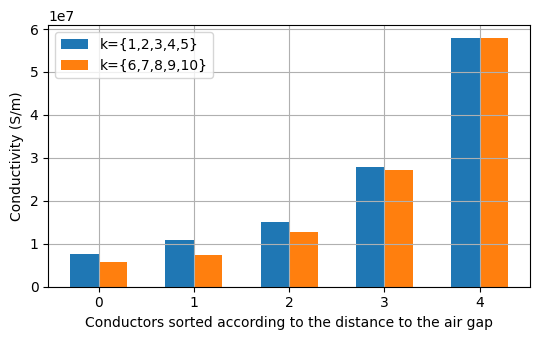

=> Joule losses = 1.07e+04 W/m


In [10]:
from utils.physics import average_property

sigma_bundle_optim = results_optim_multi_material["solution"][-1]
state = results_optim_multi_material["state"]
dico_sigma_bundle_optim = {}

for bundle in state["info"]["supply"].keys():
    dico_sigma_bundle_optim[bundle] = average_property(sigma_bundle_optim, state, zone = bundle)


import matplotlib.pyplot as plt
from numpy import arange
fig, ax = plt.subplots(figsize=(5.5, 3.5))
x = arange(0, bundles_per_half_slot)
width = 0.3
rects1 = ax.bar(x - width/2, [dico_sigma_bundle_optim["slot11_bundle"+str(i)] for i in range(bundles_per_half_slot)] , width, label = "k={1,2,3,4,5}")
rects1 = ax.bar(x + width/2, [dico_sigma_bundle_optim["slot12_bundle"+str(i)] for i in range(bundles_per_half_slot)] , width, label = "k={6,7,8,9,10}")
    
# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Conductivity (S/m)')
#ax.set_title('Optimal conductivity per half slot and bundle')
ax.set_xticks(x) ; plt.grid()
ax.set_xlabel("Conductors sorted according to the distance to the air gap")
ax.legend()
plt.tight_layout()
plt.savefig("scenes/optim/multi_material/conductivity_optim_multi_material.pdf")
plt.show()
print(f"=> Joule losses = {results_optim_multi_material["objective"][-1]:.2e} W/m")

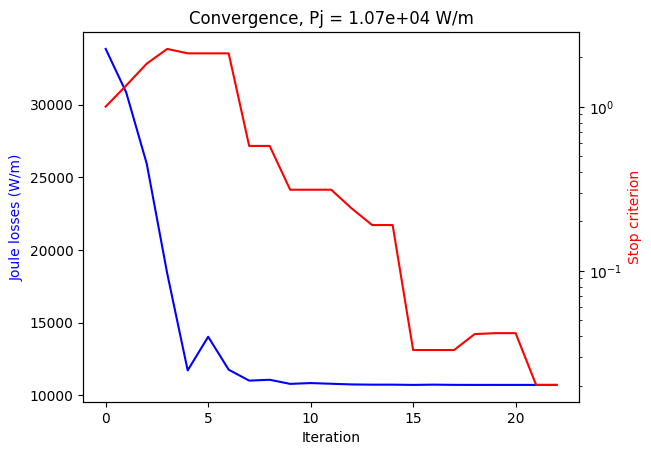

In [11]:
# Display result
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(results_optim_multi_material["objective"], 'b-')
ax2.semilogy(results_optim_multi_material["criterion"], 'r-')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Joule losses (W/m)', color='b')
ax2.set_ylabel('Stop criterion', color='r')
plt.title(f"Convergence, Pj = {results_optim_multi_material['objective'][-1]:.2e} W/m")
plt.show()

### 3.c) DC analysis

In [13]:
results_optim_multi_material_DC = solve_magnetoharmonic(fes=fes,
                                reluctivity=nu,
                                conductivity=results_optim_multi_material["solution"][-1],
                                magnetization=Mcplx,
                                frequency=1e-5,
                                supply=bundles,
                                   )

total_losses_optim = results_optim_multi_material["objective"][-1]
DC_losses_optim = joule_losses(results_optim_multi_material_DC)
AC_losses_optim = total_losses_optim - DC_losses_optim

print(f"Optimized total Joule losses: {total_losses_optim:.2e} W/m")
print(f"Optimized DC Joule losses: {DC_losses_optim:.2e} W/m ({DC_losses_optim/total_losses_optim*100:.1f} %)")
print(f"Optimized AC Joule losses: {AC_losses_optim:.2e} W/m ({AC_losses_optim/total_losses_optim*100:.1f} %)")

Optimized total Joule losses: 1.07e+04 W/m
Optimized DC Joule losses: 4.56e+03 W/m (42.5 %)
Optimized AC Joule losses: 6.17e+03 W/m (57.5 %)


___
## Summary

We find the following results after a gradient descent at $f = 1\;\text{kHz}$, for a multi-material optimization (homogeneous conductivities that have different values in each bundle):

| Total losses at 1kHz | $P_{single} = 1.07\times 10^4 \; \text{W/m}$ | 100% |
|---|---|------|
| DC losses | $P_{DC-single} = 4.56\times 10^3  \; \text{W/m}$ | 42.5 %   |
| AC losses | $P_{AC-single} = 6.17\times 10^3  \; \text{W/m}$ | 57.5 %   |

We don't have a perfect 50/50 split between AC and DC losses, however, the conductivity distribution looks close to optimality from the convergence curves.

We can do even better by relaxing the constraint of conductivity homogeneity, using for instance additive manufacturing. See
- [5_topology_optimization](5_topology_optimization.ipynb) (optimization of the conductivity at each point of the cross-section, so actually the cross-section itself, possible with additive manufacturing)
